In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

In [2]:
df = pd.read_csv("final_stock_prices.csv")

In [3]:
df.head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1972-06-01 00:00:00-04:00,1.224211,1.224211,1.224211,1.224211,0,0.0,0.0
1,1972-06-02 00:00:00-04:00,1.218877,1.218877,1.218877,1.218877,0,0.0,0.0
2,1972-06-05 00:00:00-04:00,1.194874,1.194874,1.194874,1.194874,0,0.0,0.0
3,1972-06-06 00:00:00-04:00,1.130862,1.130862,1.130862,1.130862,0,0.0,0.0
4,1972-06-07 00:00:00-04:00,1.117527,1.117527,1.117527,1.117527,0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13556 entries, 0 to 13555
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          13556 non-null  object 
 1   Open          13556 non-null  float64
 2   High          13556 non-null  float64
 3   Low           13556 non-null  float64
 4   Close         13556 non-null  float64
 5   Volume        13556 non-null  int64  
 6   Dividends     13556 non-null  float64
 7   Stock Splits  13556 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 847.4+ KB


In [5]:
df["Date"] = pd.to_datetime(df["Date"], utc=True)
df["Date"] = df["Date"].dt.tz_localize(None)
df = df.sort_values("Date")
df = df.dropna()

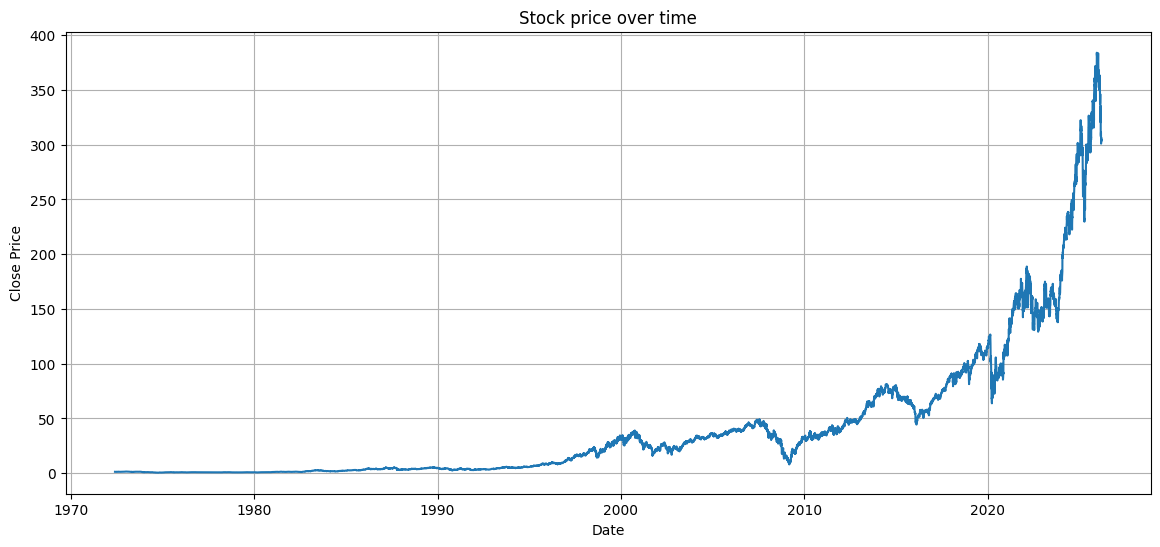

In [6]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Close"])

plt.title("Stock price over time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.grid()
plt.show()

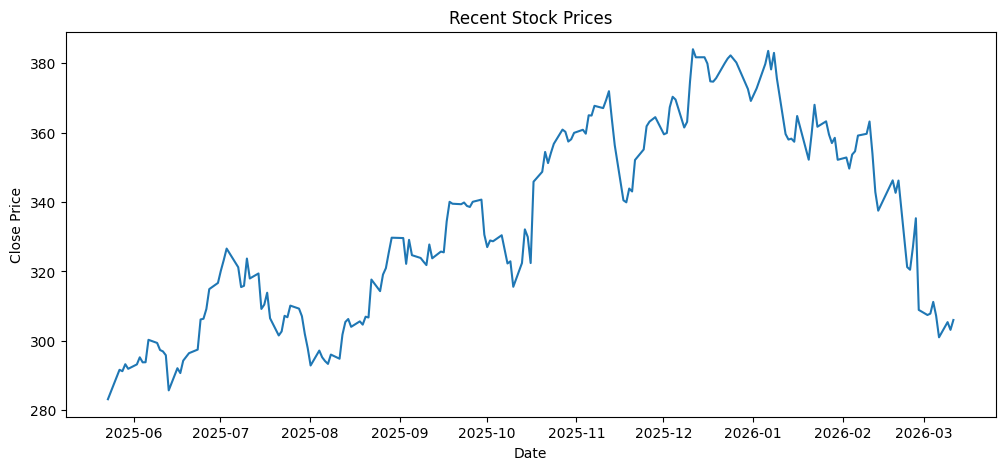

In [29]:
#recent stock prices

df_last = df.tail(200)

plt.figure(figsize=(12,5))
plt.plot(df_last["Date"], df_last["Close"])

plt.title("Recent Stock Prices")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

In [ ]:
import mplfinance as mpf

df_candle = df.copy()
df_candle.set_index("Date", inplace=True)
df_candle = df_candle[["Open", "High", "Low", "Close", "Volume"]]

mpf.plot(df_candle[-200:], type='candle', volume=True, figsize=(14,7))

In [17]:
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
df = df[:-1]

In [18]:
X = df[["Open", "High", "Low", "Close", "Volume"]]
y = df["Target"]

In [19]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name}: {acc * 100:.2f}%")

Logistic Regression: 52.56%
Decision Tree: 48.06%
Random Forest: 48.32%


In [ ]:
best_model = max(results, key = results.get)
print("\nBest Model:", best_model)

accuracy_score = results[best_model] * 100
print(f"Accuracy {accuracy_score:.3f}%")

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())

plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], utc=True)
df["Date"] = df["Date"].dt.tz_localize(None)

In [ ]:
prophet_df = df[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"})

In [ ]:
model = Prophet(daily_seasonality=True)
model.fit(prophet_df)

In [ ]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

In [ ]:
fig1= model.plot(forecast)
plt.title("Stock Price Forecast")
plt.show()

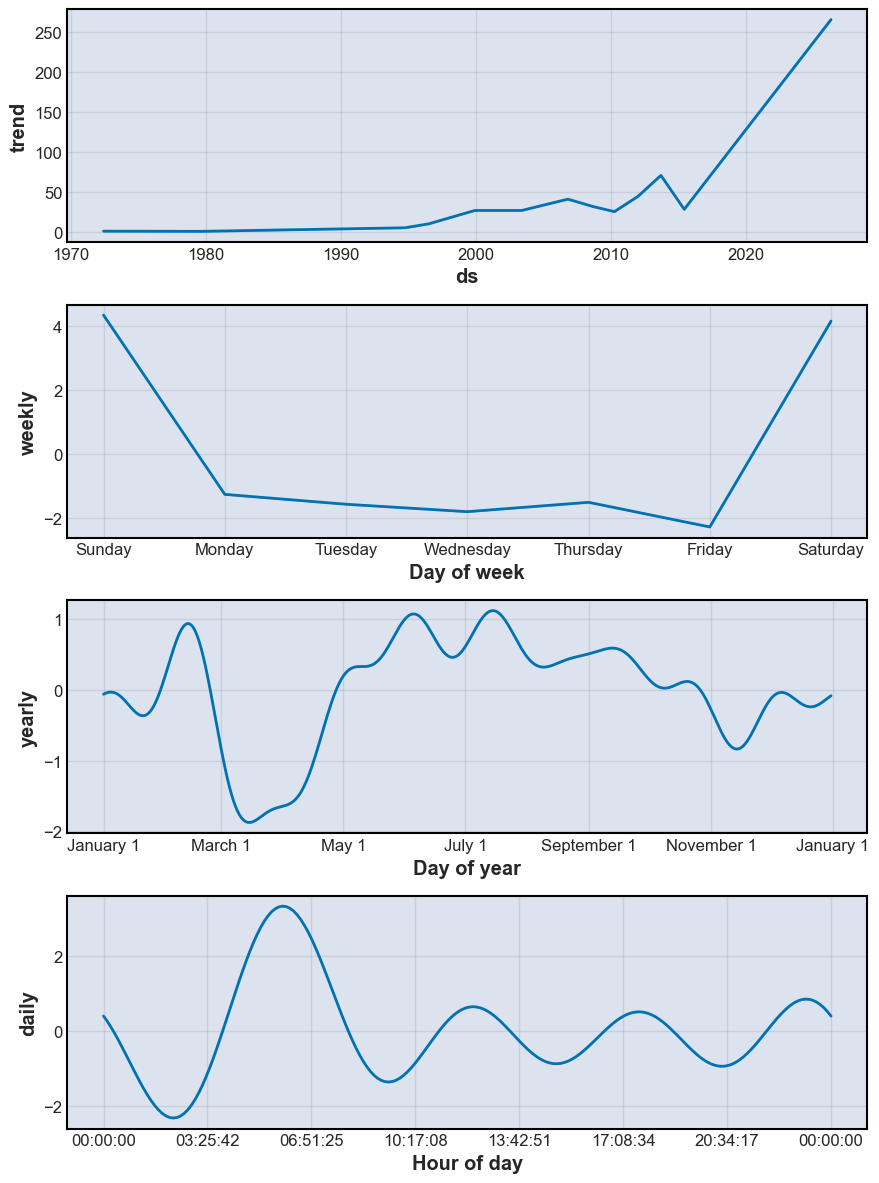

In [108]:
fig2 = model.plot_components(forecast)
plt.show()